 # Importing all the necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

#Loading the Data

In [2]:
data = pd.read_csv("./content/CreditcardDataset.csv")
data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,94.0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,...,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,0.442798,1
1,82.0,-0.600639,-0.291694,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,...,0.343618,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,0.261049,1
2,13.0,-0.839218,-0.309212,0.331263,0.975545,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,...,0.087047,-0.299007,0.091761,-1.987569,-0.219672,0.357113,1.477894,-0.518270,0.343387,1
3,43.0,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,0.097078,0.968645,-0.702053,...,-0.161286,0.404051,1.886186,0.174578,0.257550,-0.074446,-1.918771,-0.026514,0.834572,1
4,85.0,0.060230,2.463242,-0.192361,0.301547,-0.034712,-1.168678,1.142823,0.751933,0.791032,...,-1.062304,0.473592,-0.919424,1.549934,-0.783253,-0.322062,0.813517,-1.230864,0.935485,1


#Understanding the Data

In [ ]:
print(f"CSV Data set - {data.describe()}")

             Time          V1          V2          V3          V4          V5  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
mean    53.660000   -0.011359    0.154127    0.020977   -0.081194    0.076679   
std     28.119234    0.869004    1.077680    1.055845    0.993284    0.921407   
min      1.000000   -2.529560   -2.152891   -2.696887   -2.205566   -2.172670   
25%     32.000000   -0.545362   -0.508581   -0.702580   -0.808355   -0.491821   
50%     54.500000   -0.052179    0.076429    0.061244   -0.121064    0.058291   
75%     80.250000    0.620743    0.885746    0.670998    0.679963    0.623172   
max     99.000000    2.122156    2.985259    3.078881    2.493000    2.133033   

               V6          V7          V8          V9  ...         V21  \
count  100.000000  100.000000  100.000000  100.000000  ...  100.000000   
mean     0.097063    0.105497    0.339612    0.038688  ...   -0.015780   
std      0.894461    0.988219    0.999735    0.9

#Describing the Data

#Imbalance in the data

In [4]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

1.5
Fraud Cases: 60
Valid Transactions: 40


#Print the amount details for Fraudulent Transaction

In [ ]:
print("Amount details of the fraudulent transactions")
fraud.Amount.describe()

Amount details of the fraudulent transaction


count    60.000000
mean      0.503373
std       0.281717
min       0.006878
25%       0.268987
50%       0.481890
75%       0.751850
max       0.968076
Name: Amount, dtype: float64

# Print the amount details for Normal Transaction

In [ ]:
print("details of valid transactions")
valid.Amount.describe()

details of valid transaction


count    40.000000
mean      0.474986
std       0.304641
min       0.010811
25%       0.223565
50%       0.460955
75%       0.703725
max       0.983567
Name: Amount, dtype: float64

#Plotting the Correlation Matrix

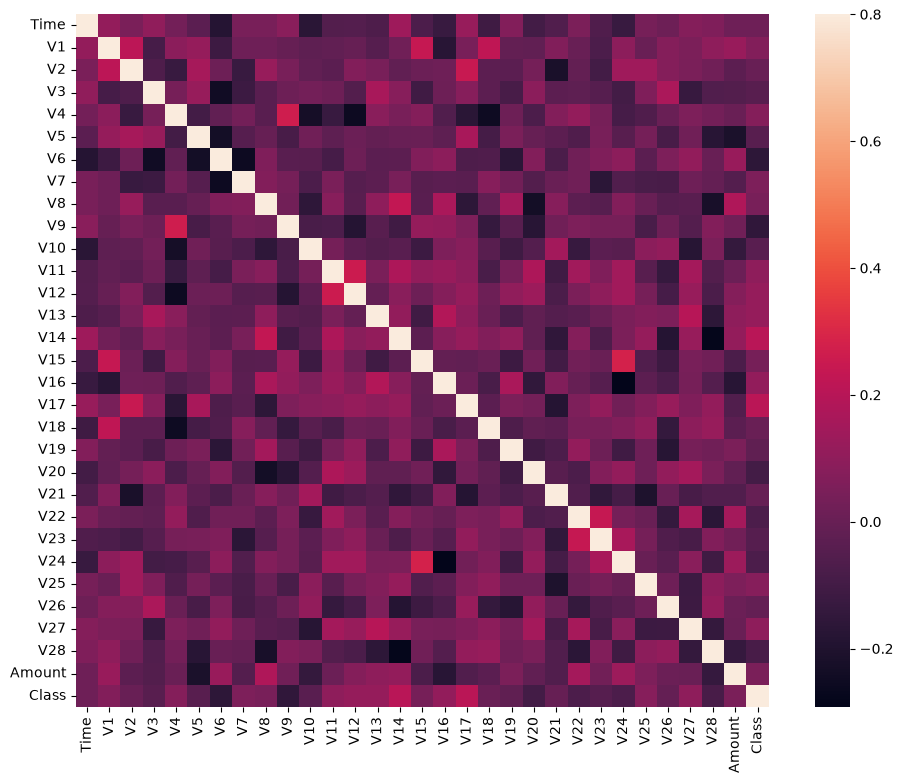

In [7]:
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

#Separating the X and the Y values

In [8]:
# dividing the X and the Y from the dataset
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
print(X.shape)
print(Y.shape)
# getting just the values for the sake of processing
# (its a numpy array with no columns)
xData = X.values
yData = Y.values

(100, 30)
(100,)


#Training and Testing Data Bifurcation

In [9]:
# Using Scikit-learn to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
xTrain, xTest, yTrain, yTest = train_test_split(
        xData, yData, test_size = 0.2, random_state = 42)


#Building a Random Forest Model using scikit learn

In [10]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(xTrain, yTrain)
# predictions
yPred = rfc.predict(xTest)

In [11]:
from sklearn.impute import SimpleImputer
print("NaN values in yTest before imputation:", np.isnan(yTest).sum())

imputer = SimpleImputer(strategy='most_frequent')
yTest = imputer.fit_transform(yTest.reshape(-1, 1)).flatten()
print("NaN values in yTest after imputation:", np.isnan(yTest).sum())

NaN values in yTest before imputation: 0
NaN values in yTest after imputation: 0


# Building all kinds of evaluating parameters

In [12]:
# Evaluating the classifier
# printing every score of the classifier
# scoring in anything
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix

n_outliers = len(fraud)
n_errors = (yPred != yTest).sum()
print("The model used is Random Forest classifier")

acc = accuracy_score(yTest, yPred)
print("The accuracy is {}".format(acc))

prec = precision_score(yTest, yPred)
print("The precision is {}".format(prec))

rec = recall_score(yTest, yPred)
print("The recall is {}".format(rec))

f1 = f1_score(yTest, yPred)
print("The F1-Score is {}".format(f1))

MCC = matthews_corrcoef(yTest, yPred)
print("The Matthews correlation coefficient is{}".format(MCC))

The model used is Random Forest classifier
The accuracy is 0.5
The precision is 0.6
The recall is 0.6923076923076923
The F1-Score is 0.6428571428571429
The Matthews correlation coefficient is-0.18156825980064073


#Visualizing the Confusion Matrix

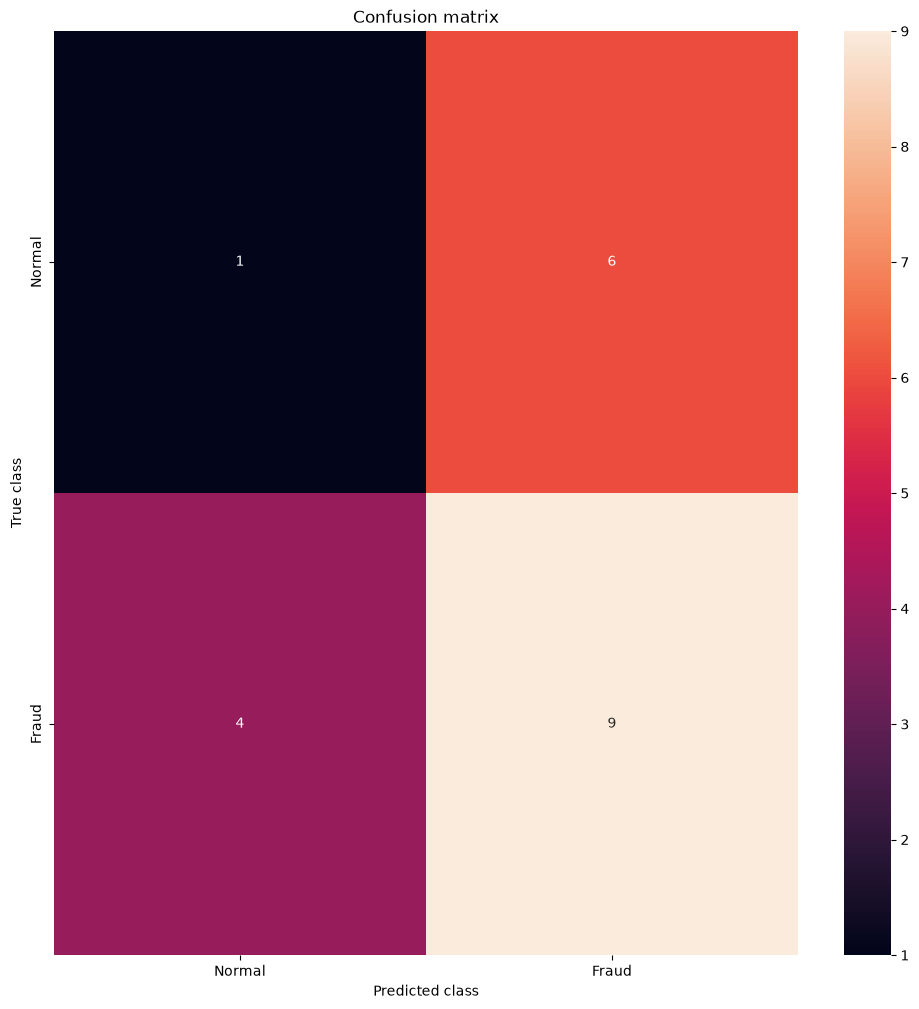

In [13]:
# printing the confusion matrix
LABELS = ['Normal', 'Fraud']
conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize =(12, 12))
sns.heatmap(conf_matrix, xticklabels = LABELS,
            yticklabels = LABELS, annot = True, fmt ="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()